# Workshop 2 — Problema 1: Detección de Fatiga Muscular en Ciclismo
**Universidad EAFIT — Introducción a la Inteligencia Artificial 2026-01**

Dataset: `YominE/Muscle_Fatigue_Cycling` — Señales EMG de 8 músculos durante sprints en bicicleta.

## Instalación y librerías

In [1]:
# Instalar dependencias
!pip install datasets -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

from datasets import load_dataset

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

random_state = 42
FS = 1000  # Frecuencia de muestreo: 1000 Hz (paso de tiempo = 0.001 s)
print('Librerías listas ✓')

c:\Users\juanm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías listas ✓


## Descarga del dataset

In [3]:
print('Descargando dataset (puede tardar 3-5 min, son ~499 MB)...')
dataset = load_dataset('YominE/Muscle_Fatigue_Cycling')
df_raw = dataset['train'].to_pandas()

print(f'✓ Shape: {df_raw.shape}')
print('Columnas:', df_raw.columns.tolist())
df_raw.head()

Descargando dataset (puede tardar 3-5 min, son ~499 MB)...


✓ Shape: (3002137, 10)
Columnas: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


## Punto 1a — Preprocesamiento del target

Se establecen únicamente 2 etiquetas:
- **0** = Condición normal
- **1** = Desgaste muscular (las etiquetas 2 se reemplazan por 1)

In [4]:
df = df_raw.copy()

print('=== TARGET ANTES ===')
print(df['Target'].value_counts())
print(f'Valores únicos: {sorted(df["Target"].unique())}')

# Reemplazar etiqueta 2 → 1 según instrucciones
df['Target'] = df['Target'].replace(2, 1)

print('\n=== TARGET DESPUÉS ===')
print(df['Target'].value_counts())
print(f'Valores únicos: {sorted(df["Target"].unique())}')
print('\n0 = Condición normal | 1 = Desgaste muscular')

=== TARGET ANTES ===
Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64
Valores únicos: [np.int64(0), np.int64(1), np.int64(2)]

=== TARGET DESPUÉS ===
Target
0    2127600
1     874537
Name: count, dtype: int64
Valores únicos: [np.int64(0), np.int64(1)]

0 = Condición normal | 1 = Desgaste muscular


## Punto 1b — Clasificación de variables

Análisis de los tipos de variables presentes en el dataset.

In [5]:
# Identificar columnas de señal
signal_cols = [col for col in df.columns if col not in ['Time', 'Target']]

print('=== CLASIFICACIÓN DE VARIABLES ===')
print(f'\nTotal columnas: {df.shape[1]}')
print(f'Total filas: {df.shape[0]:,}')

print('\n--- Variable de tiempo ---')
print(f'  Time: numérica continua (float64)')
print(f'  Rango: {df["Time"].min():.3f} s → {df["Time"].max():.3f} s')
print(f'  Paso: {df["Time"].diff().median():.4f} s → Frecuencia de muestreo: {1/df["Time"].diff().median():.0f} Hz')
print(f'  Rol: índice temporal, NO se usará como feature (indicación del enunciado)')

print(f'\n--- Variables de señal EMG ({len(signal_cols)} canales) ---')
for col in signal_cols:
    print(f'  {col}')
    print(f'    Tipo: numérica continua (float64)')
    print(f'    Rango: [{df[col].min():.4f}, {df[col].max():.4f}] mV')
    print(f'    Nulos: {df[col].isnull().sum()}')

print(f'\n--- Variable Target ---')
print(f'  Target: binaria (0=normal, 1=desgaste)')
print(f'  Tipo: categórica nominal con 2 clases → problema de CLASIFICACIÓN BINARIA')
print(f'  Distribución: {dict(df["Target"].value_counts())}')

=== CLASIFICACIÓN DE VARIABLES ===

Total columnas: 10
Total filas: 3,002,137

--- Variable de tiempo ---
  Time: numérica continua (float64)
  Rango: 0.000 s → 1741.598 s
  Paso: 0.0010 s → Frecuencia de muestreo: 1000 Hz
  Rol: índice temporal, NO se usará como feature (indicación del enunciado)

--- Variables de señal EMG (8 canales) ---
  Right Rectus femoris
    Tipo: numérica continua (float64)
    Rango: [-0.8433, 0.9921] mV
    Nulos: 0
  Left Gluteus maximus
    Tipo: numérica continua (float64)
    Rango: [-1.1173, 1.0632] mV
    Nulos: 0
  Left Gastrocnemius medialis
    Tipo: numérica continua (float64)
    Rango: [-1.7493, 1.6148] mV
    Nulos: 0
  Left Semitendinosus
    Tipo: numérica continua (float64)
    Rango: [-1.5760, 0.8686] mV
    Nulos: 0
  Left Biceps femoris caput longus
    Tipo: numérica continua (float64)
    Rango: [-0.7503, 0.8430] mV
    Nulos: 0
  Right Vastus medialis
    Tipo: numérica continua (float64)
    Rango: [-1.2166, 1.0795] mV
    Nulos: 0
  

## Punto 3a — Visualización de señales en el tiempo

Antes de extraer características, graficamos una porción de las señales para hacer una identificación inicial.

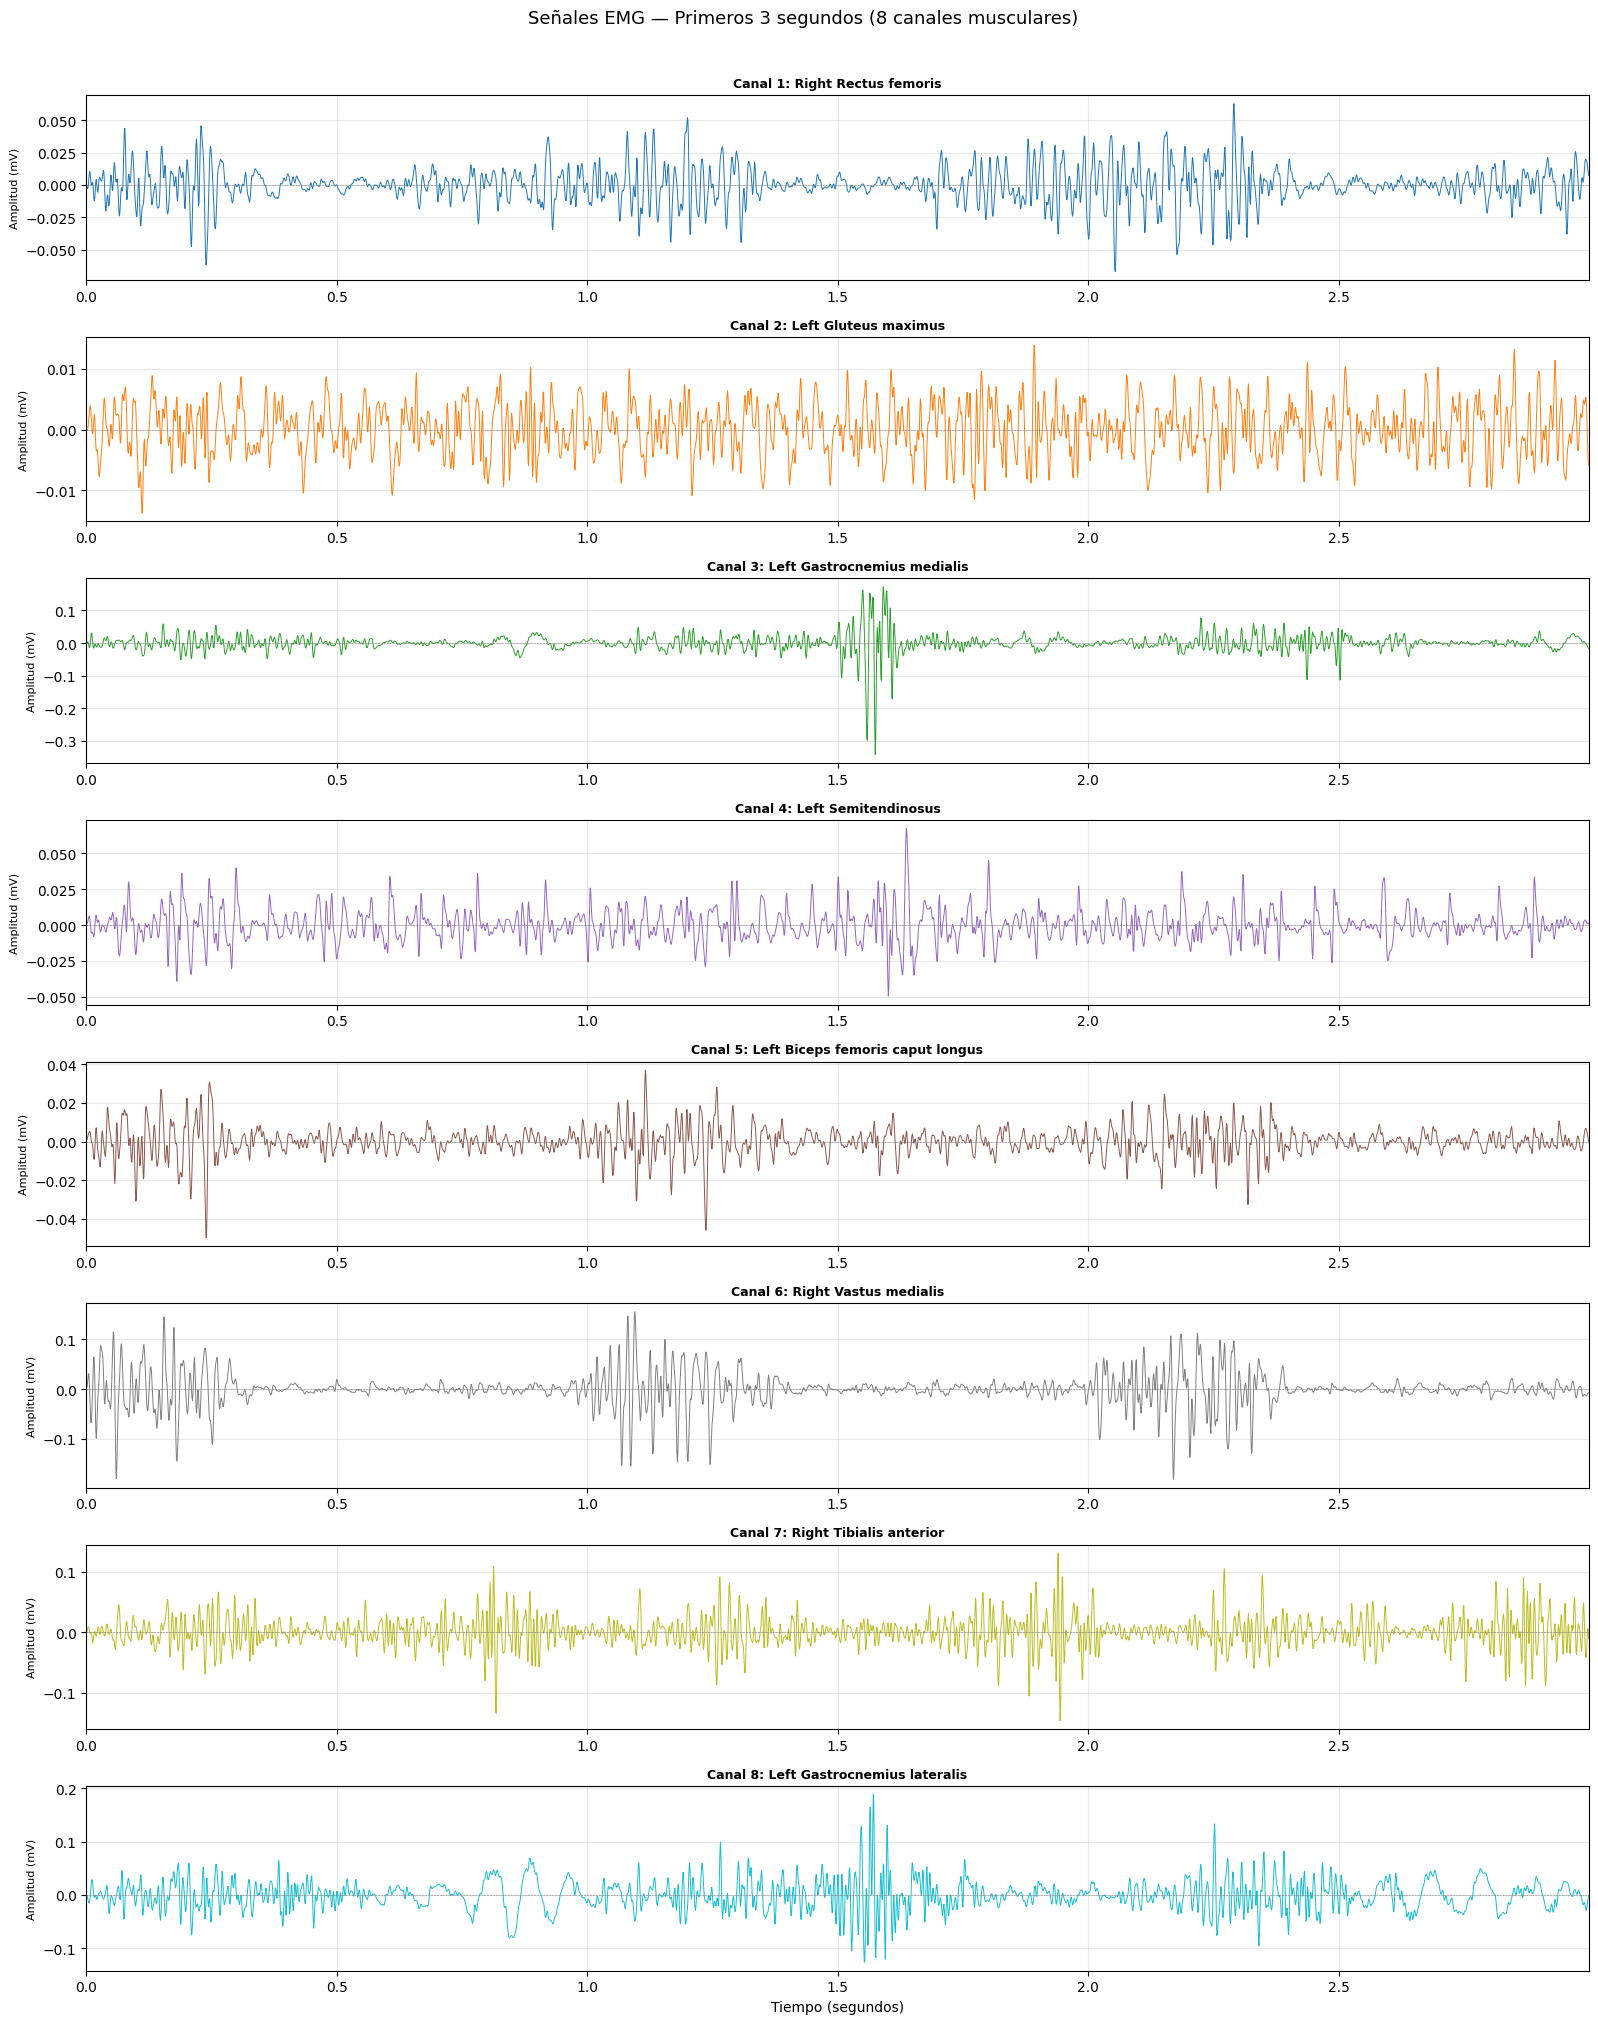

=== CONCLUSIONES INICIALES ===
1. El dataset contiene 3,002,137 muestras a 1000 Hz = 3002 segundos de señal total
2. Las señales EMG tienen amplitudes en el orden de milivoltios (pequeñas)
3. Se observan 8 canales musculares diferentes de la pierna dominante
4. Las señales presentan oscilaciones características de actividad muscular
5. La frecuencia de muestreo de 1000 Hz permite capturar frecuencias EMG hasta 500 Hz
6. En fatiga muscular se espera: mayor amplitud (RMS), menor frecuencia mediana
7. La variable Time NO se usará como feature para evitar dependencia lineal artificial con el target


In [6]:
# Graficar primeros 3000 puntos = 3 segundos
n_mostrar = 3000
tiempo_plot = df['Time'].values[:n_mostrar]

fig, axes = plt.subplots(len(signal_cols), 1, figsize=(16, 2.5 * len(signal_cols)))

colores = plt.cm.tab10(np.linspace(0, 1, len(signal_cols)))

for i, col in enumerate(signal_cols):
    valores = df[col].values[:n_mostrar]
    label_seg = df['Target'].values[:n_mostrar]

    axes[i].plot(tiempo_plot, valores, linewidth=0.7, color=colores[i])
    axes[i].set_title(f'Canal {i+1}: {col}', fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Amplitud (mV)', fontsize=8)
    axes[i].axhline(0, color='gray', linewidth=0.4, linestyle='--')
    axes[i].set_xlim(tiempo_plot[0], tiempo_plot[-1])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo (segundos)')
plt.suptitle('Señales EMG — Primeros 3 segundos (8 canales musculares)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('=== CONCLUSIONES INICIALES ===')
print(f'1. El dataset contiene {len(df):,} muestras a {FS} Hz = {len(df)/FS:.0f} segundos de señal total')
print(f'2. Las señales EMG tienen amplitudes en el orden de milivoltios (pequeñas)')
print(f'3. Se observan 8 canales musculares diferentes de la pierna dominante')
print(f'4. Las señales presentan oscilaciones características de actividad muscular')
print(f'5. La frecuencia de muestreo de {FS} Hz permite capturar frecuencias EMG hasta 500 Hz')
print(f'6. En fatiga muscular se espera: mayor amplitud (RMS), menor frecuencia mediana')
print(f'7. La variable Time NO se usará como feature para evitar dependencia lineal artificial con el target')

## Punto 2 — Feature Engineering

### Justificación de características

Se extraen **8 características por canal** (4 tiempo + 4 frecuencia) sobre ventanas de 1 segundo:

**Dominio del tiempo:**
- **RMS**: mide la potencia de la señal. Aumenta con fatiga al reclutar más unidades motoras.
- **Varianza**: dispersión de la señal. Mayor variabilidad en fatiga.
- **Zero Crossing Rate (ZCR)**: cruces por cero por segundo. Disminuye con fatiga (señal más lenta).
- **Pendiente media (MAV de la derivada)**: cambio promedio entre muestras consecutivas.
- **MAV (Mean Absolute Value)**: valor absoluto medio, indicador robusto de amplitud.

**Dominio de la frecuencia:**
- **Frecuencia mediana**: divide la potencia espectral en dos mitades. Es el indicador más usado de fatiga muscular — baja claramente con el desgaste.
- **Frecuencia media**: promedio ponderado del espectro. También baja con fatiga.
- **Potencia espectral total**: energía total de la señal en frecuencia.

In [7]:
WINDOW_SIZE = FS * 1      # 1000 muestras = 1 segundo exacto
STEP_SIZE   = FS // 2     # 500 muestras = 0.5 seg (50% de overlap entre ventanas)

def extraer_caracteristicas_canal(ventana, fs=FS):
    """
    Extrae 8 características (tiempo + frecuencia) de una ventana de señal EMG.
    
    Parámetros:
        ventana: array 1D de muestras EMG
        fs: frecuencia de muestreo en Hz
    Retorna:
        dict con 8 características
    """
    features = {}
    n = len(ventana)

    # ──────────────────────────────────────────────────────────
    # DOMINIO DEL TIEMPO
    # ──────────────────────────────────────────────────────────

    # 1. RMS (Root Mean Square)
    # Justificación: mide la potencia de la señal EMG.
    # En fatiga, el músculo recluta más unidades motoras → mayor RMS.
    features['rms'] = np.sqrt(np.mean(ventana ** 2))

    # 2. Varianza
    # Justificación: mide la dispersión de la señal.
    # Mayor varianza indica señal más irregular, típica de fatiga.
    features['varianza'] = np.var(ventana)

    # 3. Zero Crossing Rate (ZCR)
    # Justificación: número de veces que la señal cruza el cero por segundo.
    # Con fatiga, las frecuencias de la señal bajan → menos cruces por cero.
    cruces = np.where(np.diff(np.sign(ventana)))[0]
    features['zcr'] = len(cruces) / n

    # 4. Pendiente media (MAV de la derivada)
    # Justificación: captura la dinámica de cambio entre muestras.
    # Relacionada con la velocidad de cambio de la señal muscular.
    features['pendiente_media'] = np.mean(np.abs(np.diff(ventana)))

    # 5. MAV (Mean Absolute Value)
    # Justificación: indicador clásico en EMG, similar al RMS pero más robusto.
    # Aumenta con la intensidad de la contracción muscular.
    features['mav'] = np.mean(np.abs(ventana))

    # ──────────────────────────────────────────────────────────
    # DOMINIO DE LA FRECUENCIA
    # ──────────────────────────────────────────────────────────
    freqs     = fftfreq(n, d=1.0/fs)
    magnitudes = np.abs(fft(ventana))

    # Solo frecuencias positivas
    freqs_pos = freqs[:n//2]
    mag_pos   = magnitudes[:n//2]
    potencia  = mag_pos ** 2
    sum_pot   = np.sum(potencia)

    # 6. Frecuencia mediana
    # Justificación: EL indicador más importante de fatiga muscular en EMG.
    # Baja de forma consistente durante el desgaste muscular.
    # Es el estándar clínico para detectar fatiga en señales EMG.
    potencia_acum = np.cumsum(potencia)
    idx_median    = np.searchsorted(potencia_acum, sum_pot / 2)
    idx_median    = min(idx_median, len(freqs_pos) - 1)
    features['freq_mediana'] = freqs_pos[idx_median]

    # 7. Frecuencia media
    # Justificación: promedio ponderado del espectro de potencia.
    # También disminuye con fatiga muscular, complementa la frecuencia mediana.
    if sum_pot > 0:
        features['freq_media'] = np.sum(freqs_pos * potencia) / sum_pot
    else:
        features['freq_media'] = 0.0

    # 8. Potencia espectral total
    # Justificación: energía total de la señal en el dominio de la frecuencia.
    # Puede aumentar en fatiga al reclutar más unidades motoras.
    features['potencia_total'] = sum_pot

    return features


print('=== PARÁMETROS DE EXTRACCIÓN ===')
print(f'Frecuencia de muestreo: {FS} Hz')
print(f'Tamaño de ventana: {WINDOW_SIZE} muestras = {WINDOW_SIZE/FS:.1f} segundo')
print(f'Paso entre ventanas: {STEP_SIZE} muestras = {STEP_SIZE/FS:.2f} segundos (50% overlap)')
print(f'\nCaracterísticas por canal: 8 (5 tiempo + 3 frecuencia)')
print(f'Canales EMG: {len(signal_cols)}')
print(f'Total features por ventana: 8 × {len(signal_cols)} = {8 * len(signal_cols)}')

=== PARÁMETROS DE EXTRACCIÓN ===
Frecuencia de muestreo: 1000 Hz
Tamaño de ventana: 1000 muestras = 1.0 segundo
Paso entre ventanas: 500 muestras = 0.50 segundos (50% overlap)

Características por canal: 8 (5 tiempo + 3 frecuencia)
Canales EMG: 8
Total features por ventana: 8 × 8 = 64


In [8]:
# ⚠️ Esta celda puede tardar 5-15 minutos dependiendo de Colab
print('Extrayendo características por ventanas deslizantes...')
print(f'Dataset: {len(df):,} muestras | Ventana: {WINDOW_SIZE} | Paso: {STEP_SIZE}')

valores_signal = df[signal_cols].values
labels_arr     = df['Target'].values

n_ventanas_est = (len(df) - WINDOW_SIZE) // STEP_SIZE
print(f'Ventanas estimadas: ~{n_ventanas_est:,}')

rows = []
indices = range(0, len(df) - WINDOW_SIZE, STEP_SIZE)

for k, start in enumerate(indices):
    end  = start + WINDOW_SIZE
    fila = {}

    for j, col in enumerate(signal_cols):
        ventana      = valores_signal[start:end, j]
        feats        = extraer_caracteristicas_canal(ventana)
        nombre_canal = col.replace(' ', '_').replace('(', '').replace(')', '')
        for nombre_feat, valor in feats.items():
            fila[f'{nombre_canal}__{nombre_feat}'] = valor

    # Label de la ventana: redondeado de la media de etiquetas en esa ventana
    fila['Target'] = int(np.round(np.mean(labels_arr[start:end])))
    rows.append(fila)

    if (k + 1) % 500 == 0:
        print(f'  Procesadas {k+1:,} / {n_ventanas_est:,} ventanas...')

df_features = pd.DataFrame(rows)

print(f'\n✓ Extracción completa!')
print(f'Shape del nuevo dataset de características: {df_features.shape}')
print(f'\nDistribución del target:')
print(df_features['Target'].value_counts())
print(df_features['Target'].value_counts(normalize=True).round(3))
df_features.head()

Extrayendo características por ventanas deslizantes...
Dataset: 3,002,137 muestras | Ventana: 1000 | Paso: 500
Ventanas estimadas: ~6,002
  Procesadas 500 / 6,002 ventanas...
  Procesadas 1,000 / 6,002 ventanas...
  Procesadas 1,500 / 6,002 ventanas...
  Procesadas 2,000 / 6,002 ventanas...
  Procesadas 2,500 / 6,002 ventanas...
  Procesadas 3,000 / 6,002 ventanas...
  Procesadas 3,500 / 6,002 ventanas...
  Procesadas 4,000 / 6,002 ventanas...
  Procesadas 4,500 / 6,002 ventanas...
  Procesadas 5,000 / 6,002 ventanas...
  Procesadas 5,500 / 6,002 ventanas...
  Procesadas 6,000 / 6,002 ventanas...

✓ Extracción completa!
Shape del nuevo dataset de características: (6003, 65)

Distribución del target:
Target
0    4255
1    1748
Name: count, dtype: int64
Target
0    0.709
1    0.291
Name: proportion, dtype: float64


,Right_Rectus_femoris__rms,Right_Rectus_femoris__varianza,Right_Rectus_femoris__zcr,Right_Rectus_femoris__pendiente_media,Right_Rectus_femoris__mav,Right_Rectus_femoris__freq_mediana,Right_Rectus_femoris__freq_media,Right_Rectus_femoris__potencia_total,Left_Gluteus_maximus__rms,Left_Gluteus_maximus__varianza,...,Right_Tibialis_anterior__potencia_total,Left_Gastrocnemius_lateralis__rms,Left_Gastrocnemius_lateralis__varianza,Left_Gastrocnemius_lateralis__zcr,Left_Gastrocnemius_lateralis__pendiente_media,Left_Gastrocnemius_lateralis__mav,Left_Gastrocnemius_lateralis__freq_mediana,Left_Gastrocnemius_lateralis__freq_media,Left_Gastrocnemius_lateralis__potencia_total,Target
0,0.011706,0.000137,0.123,0.003076,0.008125,46.0,55.438509,68.513607,0.003989,0.000016,...,267.640330,0.025655,0.000658,0.120,0.006508,0.019441,15.0,41.725911,329.110828,0
1,0.012752,0.000163,0.120,0.003356,0.008979,50.0,55.399930,81.309835,0.003945,0.000016,...,288.380555,0.026479,0.000701,0.108,0.006364,0.020276,14.0,40.322547,350.612104,0
2,0.014023,0.000197,0.111,0.003891,0.010118,54.0,57.771363,98.329357,0.004223,0.000018,...,327.028242,0.031409,0.000986,0.149,0.011270,0.021678,76.0,78.891412,493.321788,0
3,0.016186,0.000262,0.107,0.004410,0.011668,53.0,55.984746,130.995558,0.004316,0.000019,...,317.921014,0.033080,0.001094,0.155,0.011907,0.022561,75.0,80.663707,547.158285,0
4,0.014820,0.000220,0.121,0.003840,0.010151,50.0,56.099308,109.830717,0.004209,0.000018,...,294.692829,0.026209,0.000687,0.101,0.007284,0.020389,50.0,55.348964,343.456965,0


## Punto 3 — EDA Completo sobre el dataset de características

In [9]:
feat_cols = [c for c in df_features.columns if c != 'Target']

print('=== ESTADÍSTICOS DESCRIPTIVOS ===')
print(f'Shape: {df_features.shape}')
print(f'Features: {len(feat_cols)}')
print(f'\nValores nulos por columna:')
nulos = df_features.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay valores nulos ✓')
print(f'\nEstadísticos descriptivos (primeras 10 features):')
df_features[feat_cols[:10]].describe().round(4)

=== ESTADÍSTICOS DESCRIPTIVOS ===
Shape: (6003, 65)
Features: 64

Valores nulos por columna:
No hay valores nulos ✓

Estadísticos descriptivos (primeras 10 features):


,Right_Rectus_femoris__rms,Right_Rectus_femoris__varianza,Right_Rectus_femoris__zcr,Right_Rectus_femoris__pendiente_media,Right_Rectus_femoris__mav,Right_Rectus_femoris__freq_mediana,Right_Rectus_femoris__freq_media,Right_Rectus_femoris__potencia_total,Left_Gluteus_maximus__rms,Left_Gluteus_maximus__varianza
count,6003.0000,6003.0000,6003.0000,6003.0000,6003.0000,6003.0000,6003.0000,6003.0000,6003.0000,6003.0000
mean,0.0357,0.0019,0.1089,0.0082,0.0226,47.4968,54.2778,934.5016,0.0117,0.0005
std,0.0243,0.0036,0.0131,0.0055,0.0152,7.7487,5.8012,1792.8627,0.0178,0.0025
min,0.0029,0.0000,0.0620,0.0009,0.0020,16.0000,20.7289,4.3049,0.0028,0.0000
25%,0.0214,0.0005,0.1000,0.0050,0.0134,43.0000,51.2055,229.1488,0.0054,0.0000
50%,0.0301,0.0009,0.1090,0.0069,0.0187,48.0000,54.7541,454.0602,0.0070,0.0000
75%,0.0422,0.0018,0.1180,0.0095,0.0270,53.0000,57.9946,889.2188,0.0108,0.0001
max,0.2060,0.0424,0.1550,0.0473,0.1350,74.0000,70.8317,21210.9970,0.2061,0.0425


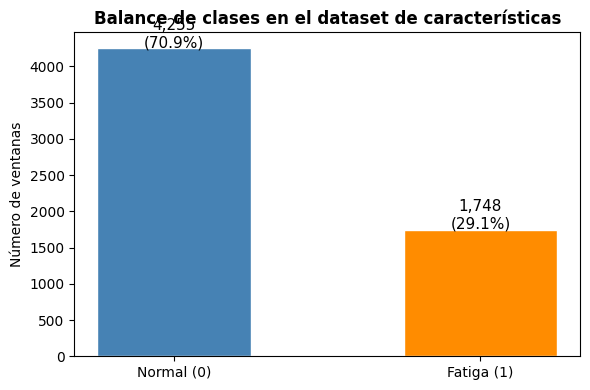

Ratio desbalance: 2.43:1
⚠️  Hay desbalance de clases. Se recomienda usar class_weight="balanced" en los modelos.


In [10]:
# ── Balance de clases ──────────────────────────────────────────────────────
conteo = df_features['Target'].value_counts()
pct    = df_features['Target'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Fatiga (1)'], conteo.values,
              color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
ax.set_title('Balance de clases en el dataset de características', fontweight='bold')
ax.set_ylabel('Número de ventanas')
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    ax.text(i, v + 10, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

ratio = conteo.max() / conteo.min()
print(f'Ratio desbalance: {ratio:.2f}:1')
if ratio > 1.5:
    print('⚠️  Hay desbalance de clases. Se recomienda usar class_weight="balanced" en los modelos.')
else:
    print('✓ Clases razonablemente balanceadas.')

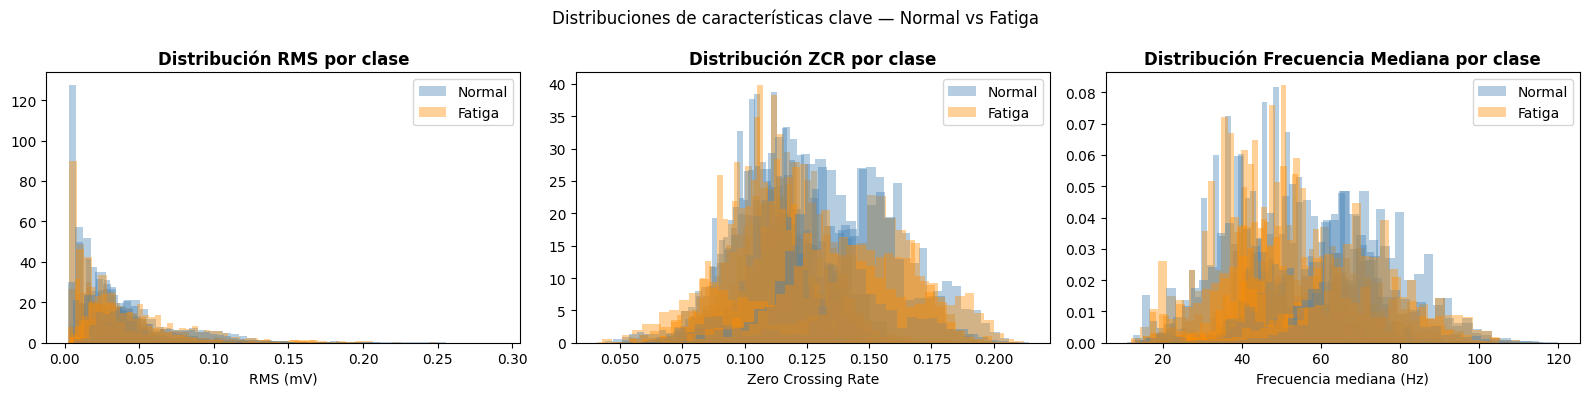

Interpretación:
- Si las distribuciones se separan entre clases → la característica es discriminativa
- Frecuencia mediana suele mostrar la mayor separación (baja en fatiga)
- RMS tiende a ser mayor en fatiga (más activación muscular)


In [11]:
# ── Distribuciones de características por tipo ─────────────────────────────
# Seleccionar una característica representativa por tipo para cada canal
rms_cols    = [c for c in feat_cols if c.endswith('__rms')]
zcr_cols    = [c for c in feat_cols if c.endswith('__zcr')]
fmed_cols   = [c for c in feat_cols if c.endswith('__freq_mediana')]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for col in rms_cols:
    for clase, color in [(0, 'steelblue'), (1, 'darkorange')]:
        datos = df_features[df_features['Target'] == clase][col]
        axes[0].hist(datos, bins=40, alpha=0.4, color=color, density=True)
axes[0].set_title('Distribución RMS por clase', fontweight='bold')
axes[0].set_xlabel('RMS (mV)')
axes[0].legend(['Normal', 'Fatiga'])

for col in zcr_cols:
    for clase, color in [(0, 'steelblue'), (1, 'darkorange')]:
        datos = df_features[df_features['Target'] == clase][col]
        axes[1].hist(datos, bins=40, alpha=0.4, color=color, density=True)
axes[1].set_title('Distribución ZCR por clase', fontweight='bold')
axes[1].set_xlabel('Zero Crossing Rate')
axes[1].legend(['Normal', 'Fatiga'])

for col in fmed_cols:
    for clase, color in [(0, 'steelblue'), (1, 'darkorange')]:
        datos = df_features[df_features['Target'] == clase][col]
        axes[2].hist(datos, bins=40, alpha=0.4, color=color, density=True)
axes[2].set_title('Distribución Frecuencia Mediana por clase', fontweight='bold')
axes[2].set_xlabel('Frecuencia mediana (Hz)')
axes[2].legend(['Normal', 'Fatiga'])

plt.suptitle('Distribuciones de características clave — Normal vs Fatiga', fontsize=12)
plt.tight_layout()
plt.show()

print('Interpretación:')
print('- Si las distribuciones se separan entre clases → la característica es discriminativa')
print('- Frecuencia mediana suele mostrar la mayor separación (baja en fatiga)')
print('- RMS tiende a ser mayor en fatiga (más activación muscular)')

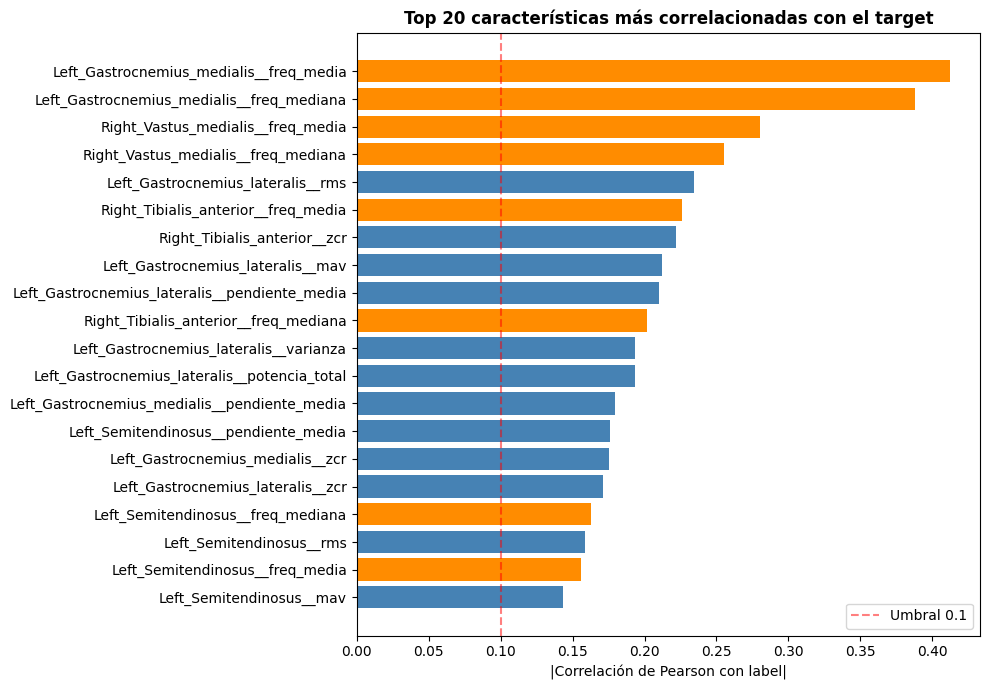


Top 10 features más correlacionadas con el target:
Left_Gastrocnemius_medialis__freq_media          0.4126
Left_Gastrocnemius_medialis__freq_mediana        0.3880
Right_Vastus_medialis__freq_media                0.2801
Right_Vastus_medialis__freq_mediana              0.2550
Left_Gastrocnemius_lateralis__rms                0.2343
Right_Tibialis_anterior__freq_media              0.2258
Right_Tibialis_anterior__zcr                     0.2220
Left_Gastrocnemius_lateralis__mav                0.2120
Left_Gastrocnemius_lateralis__pendiente_media    0.2101
Right_Tibialis_anterior__freq_mediana            0.2020
dtype: float64

Naranja = dominio frecuencia | Azul = dominio tiempo


In [12]:
# ── Correlación de características con el target ───────────────────────────
corr_target = df_features[feat_cols].corrwith(
    df_features['Target']
).abs().sort_values(ascending=False)

top20 = corr_target.head(20)

plt.figure(figsize=(10, 7))
colores_barra = ['darkorange' if 'freq' in c else 'steelblue' for c in top20.index]
plt.barh(top20.index[::-1], top20.values[::-1], color=colores_barra[::-1])
plt.title('Top 20 características más correlacionadas con el target', fontweight='bold')
plt.xlabel('|Correlación de Pearson con label|')
plt.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='Umbral 0.1')
plt.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 features más correlacionadas con el target:')
print(corr_target.head(10).round(4))
print('\nNaranja = dominio frecuencia | Azul = dominio tiempo')

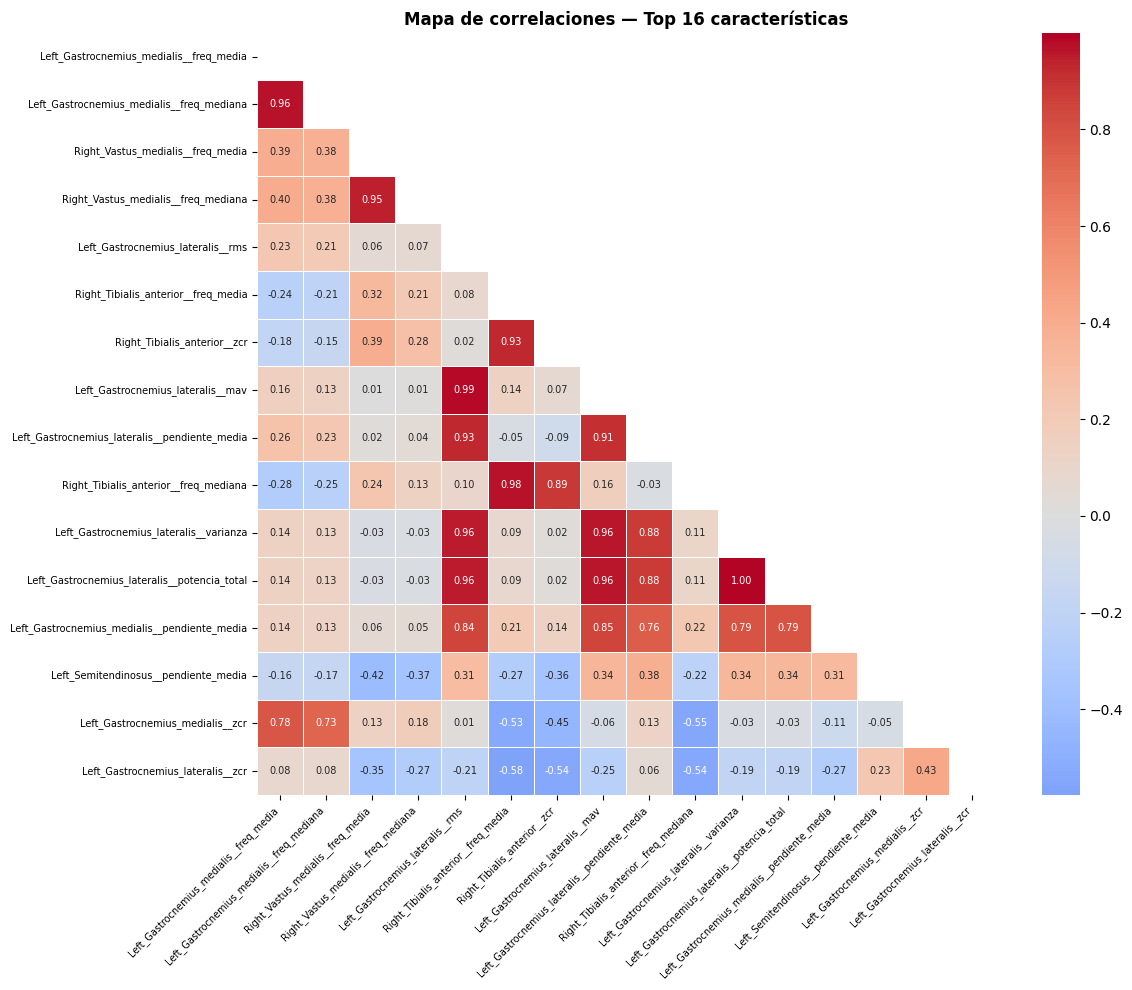

Interpretación:
- Rojo intenso = alta correlación positiva entre features
- Azul intenso = alta correlación negativa
- Features muy correlacionadas entre sí aportan información redundante


In [13]:
# ── Mapa de correlaciones entre características (muestra) ──────────────────
# Usar top 16 features para no saturar el mapa
top16 = corr_target.head(16).index.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_features[top16].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Mapa de correlaciones — Top 16 características', fontweight='bold')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

print('Interpretación:')
print('- Rojo intenso = alta correlación positiva entre features')
print('- Azul intenso = alta correlación negativa')
print('- Features muy correlacionadas entre sí aportan información redundante')

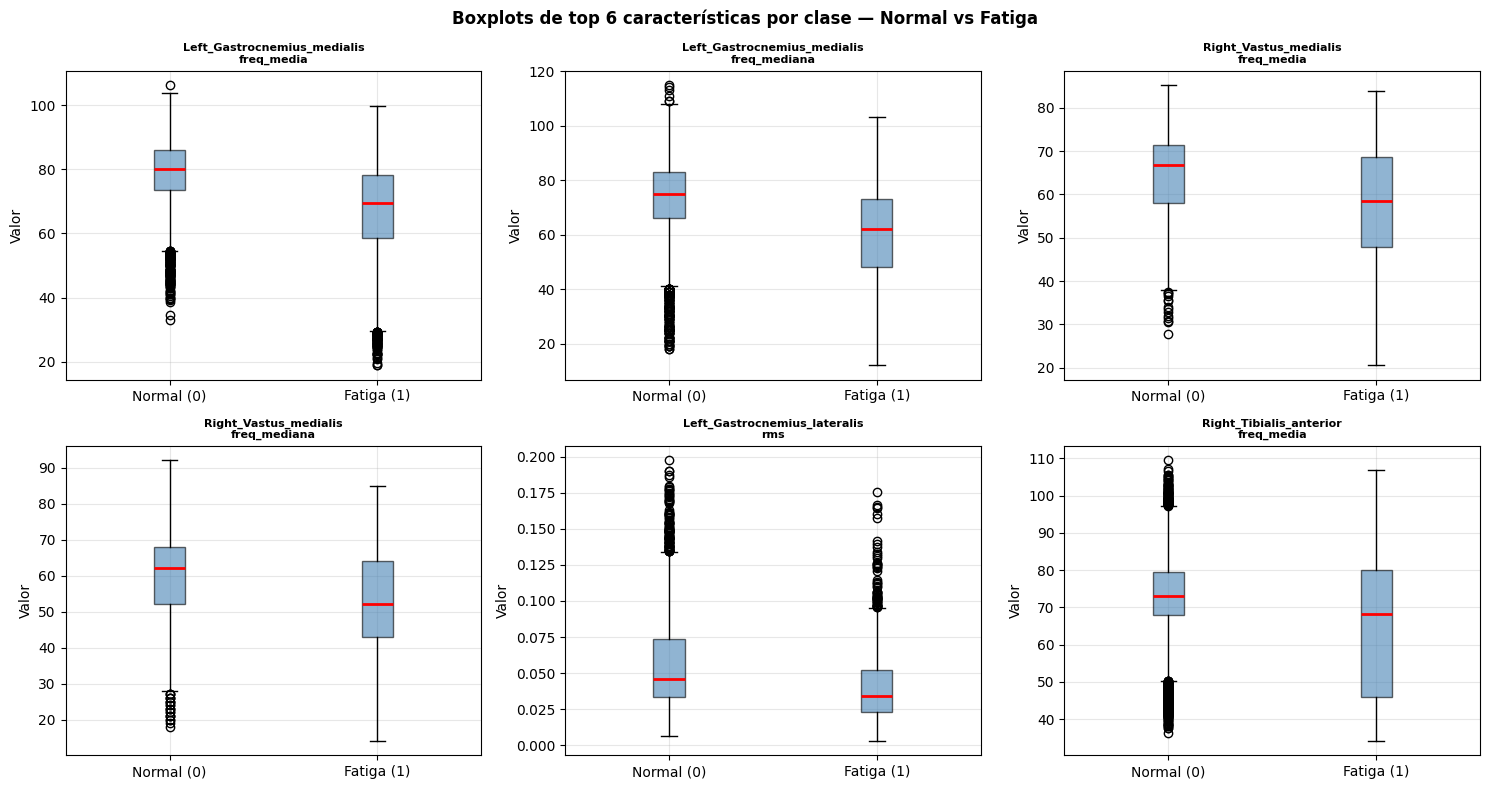

Interpretación:
- Si las cajas de Normal y Fatiga no se solapan → la feature separa bien las clases
- La línea roja es la mediana — diferencias en mediana indican separabilidad
- Cajas grandes = alta variabilidad dentro de esa clase


In [14]:
# ── Boxplots de características clave por clase ────────────────────────────
top6_features = corr_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top6_features):
    datos_0 = df_features[df_features['Target'] == 0][feat]
    datos_1 = df_features[df_features['Target'] == 1][feat]

    axes[i].boxplot([datos_0, datos_1],
                    labels=['Normal (0)', 'Fatiga (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat.replace('__', '\n'), fontsize=8, fontweight='bold')
    axes[i].set_ylabel('Valor')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots de top 6 características por clase — Normal vs Fatiga',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretación:')
print('- Si las cajas de Normal y Fatiga no se solapan → la feature separa bien las clases')
print('- La línea roja es la mediana — diferencias en mediana indican separabilidad')
print('- Cajas grandes = alta variabilidad dentro de esa clase')

## Punto 4 — Procesamiento de datos y división Train/Val/Test

Se divide en proporciones **70% / 15% / 15%** usando `stratify` para preservar el balance de clases en cada conjunto.

In [15]:
X = df_features.drop(columns=['Target'])
y = df_features['Target']

# Split 1: separar test 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=random_state,
    stratify=y   # preserva la proporción de clases en train y test
)

# Split 2: del 85% restante, separar val (~17.6% del 85% = 15% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=random_state,
    stratify=y_temp
)

print('=== DIVISIÓN DE DATOS ===')
print(f'Train : {X_train.shape} → {len(X_train)/len(X)*100:.1f}% del total')
print(f'Val   : {X_val.shape}   → {len(X_val)/len(X)*100:.1f}% del total')
print(f'Test  : {X_test.shape}  → {len(X_test)/len(X)*100:.1f}% del total')
print(f'\nJustificación: 70/15/15 es adecuado para este tamaño de dataset.')
print(f'Se usa stratify para preservar la proporción de clases en cada split.')

# ── Pipeline de preprocesamiento ───────────────────────────────────────────
preprocess_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # manejo de nulos con mediana
    ('scaler',  StandardScaler())                   # estandarización z-score
])

# fit SOLO en train — transform en val y test
X_train_p = preprocess_pipe.fit_transform(X_train)
X_val_p   = preprocess_pipe.transform(X_val)
X_test_p  = preprocess_pipe.transform(X_test)

print(f'\nPipeline de preprocesamiento aplicado:')
print(f'  SimpleImputer(strategy=median) → maneja posibles NaN con la mediana')
print(f'  StandardScaler → estandariza a media=0 y std=1')
print(f'  fit() solo en X_train para evitar data leakage ✓')

=== DIVISIÓN DE DATOS ===
Train : (4204, 64) → 70.0% del total
Val   : (898, 64)   → 15.0% del total
Test  : (901, 64)  → 15.0% del total

Justificación: 70/15/15 es adecuado para este tamaño de dataset.
Se usa stratify para preservar la proporción de clases en cada split.

Pipeline de preprocesamiento aplicado:
  SimpleImputer(strategy=median) → maneja posibles NaN con la mediana
  StandardScaler → estandariza a media=0 y std=1
  fit() solo en X_train para evitar data leakage ✓


## Punto 5 — Entrenamiento y comparación de modelos

Se entrenan 4 modelos (kNN, Decision Tree, Random Forest, Gradient Boosting) con ajuste de hiperparámetros mediante GridSearchCV y RandomizedSearchCV.

In [16]:
# Función de evaluación
def evaluar_modelo(nombre, modelo, X, y, conjunto):
    y_pred = modelo.predict(X)
    return {
        'Modelo':    nombre,
        'Conjunto':  conjunto,
        'Accuracy':  round(accuracy_score(y, y_pred), 4),
        'Precision': round(precision_score(y, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y, y_pred, zero_division=0), 4)
    }

print('Función evaluar_modelo definida ✓')

Función evaluar_modelo definida ✓


In [17]:
# ── 5a. kNN con GridSearchCV ───────────────────────────────────────────────
print('Entrenando kNN con GridSearchCV...')
knn_params = {
    'n_neighbors': [3, 5, 11, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
knn_grid.fit(X_train_p, y_train)
print(f'  Mejores params: {knn_grid.best_params_}')
print(f'  Mejor F1 (CV): {knn_grid.best_score_:.4f}')

Entrenando kNN con GridSearchCV...
  Mejores params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  Mejor F1 (CV): 0.8106


In [18]:
# ── 5b. Decision Tree con GridSearchCV ────────────────────────────────────
print('Entrenando Decision Tree con GridSearchCV...')
dt_params = {
    'max_depth':        [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'criterion':        ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=random_state, class_weight='balanced'),
    dt_params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train_p, y_train)
print(f'  Mejores params: {dt_grid.best_params_}')
print(f'  Mejor F1 (CV): {dt_grid.best_score_:.4f}')

Entrenando Decision Tree con GridSearchCV...
  Mejores params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1}
  Mejor F1 (CV): 0.7086


In [19]:
# ── 5c. Random Forest con RandomizedSearchCV ──────────────────────────────
print('Entrenando Random Forest con RandomizedSearchCV...')
rf_params = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features':     ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=random_state, class_weight='balanced'),
    rf_params,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=random_state,
    verbose=1
)
rf_search.fit(X_train_p, y_train)
print(f'  Mejores params: {rf_search.best_params_}')
print(f'  Mejor F1 (CV): {rf_search.best_score_:.4f}')

Entrenando Random Forest con RandomizedSearchCV...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Mejores params: {'n_estimators': 50, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 20}
  Mejor F1 (CV): 0.8056


In [20]:
# ── 5d. Gradient Boosting con GridSearchCV ────────────────────────────────
print('Entrenando Gradient Boosting con GridSearchCV...')
gb_params = {
    'n_estimators':  [50, 100],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=random_state),
    gb_params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train_p, y_train)
print(f'  Mejores params: {gb_grid.best_params_}')
print(f'  Mejor F1 (CV): {gb_grid.best_score_:.4f}')
print('\n✓ Los 4 modelos entrenados!')

Entrenando Gradient Boosting con GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  Mejores params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
  Mejor F1 (CV): 0.7948

✓ Los 4 modelos entrenados!


In [21]:
# ── Punto 5c: Tabla comparativa de métricas Train y Val ───────────────────
modelos_dict = {
    'kNN':              knn_grid,
    'DecisionTree':     dt_grid,
    'RandomForest':     rf_search,
    'GradientBoosting': gb_grid
}

resultados = []
for nombre, modelo in modelos_dict.items():
    resultados.append(evaluar_modelo(nombre, modelo, X_train_p, y_train, 'Train'))
    resultados.append(evaluar_modelo(nombre, modelo, X_val_p,   y_val,   'Val'))

df_resultados = pd.DataFrame(resultados)
print('=== TABLA COMPARATIVA DE MÉTRICAS ===')
print(df_resultados.to_string(index=False))

=== TABLA COMPARATIVA DE MÉTRICAS ===
          Modelo Conjunto  Accuracy  Precision  Recall     F1
             kNN    Train    1.0000     1.0000  1.0000 1.0000
             kNN      Val    0.8953     0.8500  0.7786 0.8127
    DecisionTree    Train    0.9472     0.8866  0.9387 0.9119
    DecisionTree      Val    0.8419     0.7273  0.7328 0.7300
    RandomForest    Train    0.9710     0.9332  0.9698 0.9511
    RandomForest      Val    0.8875     0.8207  0.7863 0.8031
GradientBoosting    Train    0.9995     1.0000  0.9984 0.9992
GradientBoosting      Val    0.8987     0.8608  0.7786 0.8176


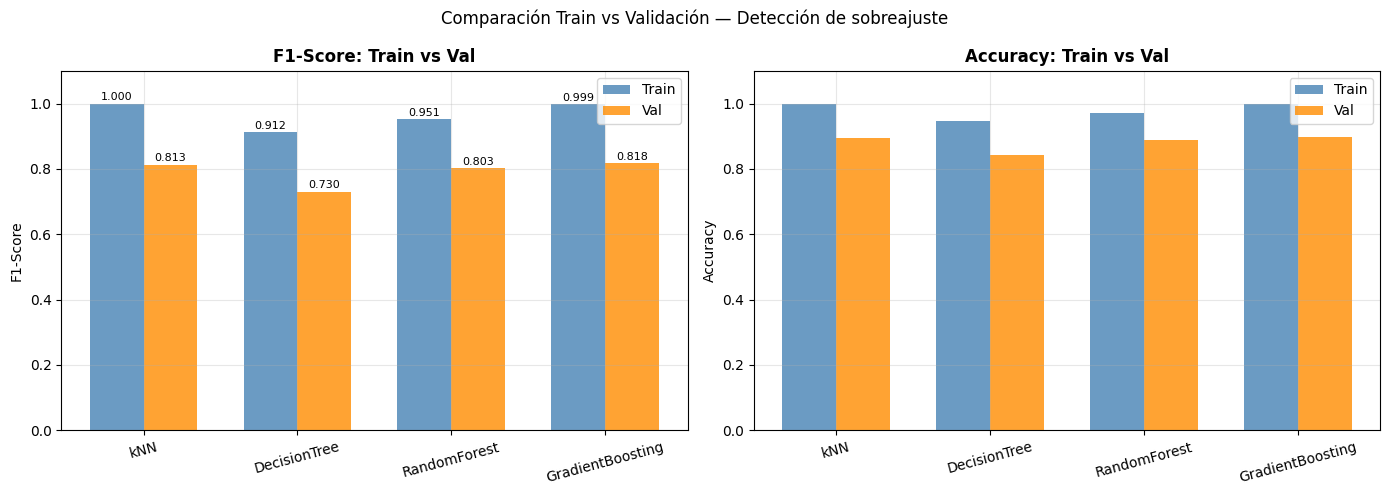


=== PUNTO 5e: ANÁLISIS DE RESULTADOS ===
  kNN: Train F1=1.000, Val F1=0.813, diff=0.187 → ❌ SOBREAJUSTE (Train >> Val)
  DecisionTree: Train F1=0.912, Val F1=0.730, diff=0.182 → ❌ SOBREAJUSTE (Train >> Val)
  RandomForest: Train F1=0.951, Val F1=0.803, diff=0.148 → ✅ Generaliza bien
  GradientBoosting: Train F1=0.999, Val F1=0.818, diff=0.182 → ❌ SOBREAJUSTE (Train >> Val)


In [22]:
# ── Punto 5d: Curvas Train vs Val (F1 por modelo) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = list(modelos_dict.keys())
f1_train = [evaluar_modelo(n, m, X_train_p, y_train, 'Train')['F1'] for n, m in modelos_dict.items()]
f1_val   = [evaluar_modelo(n, m, X_val_p,   y_val,   'Val')['F1']   for n, m in modelos_dict.items()]
acc_train = [evaluar_modelo(n, m, X_train_p, y_train, 'Train')['Accuracy'] for n, m in modelos_dict.items()]
acc_val   = [evaluar_modelo(n, m, X_val_p,   y_val,   'Val')['Accuracy']   for n, m in modelos_dict.items()]

x = np.arange(len(nombres))
width = 0.35

axes[0].bar(x - width/2, f1_train, width, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, f1_val,   width, label='Val',   color='darkorange', alpha=0.8)
axes[0].set_title('F1-Score: Train vs Val', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, rotation=15)
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, (t, v) in enumerate(zip(f1_train, f1_val)):
    axes[0].text(i - width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

axes[1].bar(x - width/2, acc_train, width, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, acc_val,   width, label='Val',   color='darkorange', alpha=0.8)
axes[1].set_title('Accuracy: Train vs Val', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres, rotation=15)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación Train vs Validación — Detección de sobreajuste', fontsize=12)
plt.tight_layout()
plt.show()

print('\n=== PUNTO 5e: ANÁLISIS DE RESULTADOS ===')
for nombre, f1_t, f1_v in zip(nombres, f1_train, f1_val):
    diff = f1_t - f1_v
    if diff > 0.15:
        estado = '❌ SOBREAJUSTE (Train >> Val)'
    elif f1_t < 0.70 and f1_v < 0.70:
        estado = '⚠️  SUBAJUSTE (ambos bajos)'
    else:
        estado = '✅ Generaliza bien'
    print(f'  {nombre}: Train F1={f1_t:.3f}, Val F1={f1_v:.3f}, diff={diff:.3f} → {estado}')

In [23]:
# ── Punto 5e: Selección del mejor modelo ──────────────────────────────────
f1_val_dict = {
    nombre: f1_score(y_val, modelo.predict(X_val_p), zero_division=0)
    for nombre, modelo in modelos_dict.items()
}

mejor_nombre = max(f1_val_dict, key=f1_val_dict.get)
mejor_modelo_gs = modelos_dict[mejor_nombre]

print('=== SELECCIÓN DEL MEJOR MODELO ===')
print('F1-Score en validación por modelo:')
for n, v in sorted(f1_val_dict.items(), key=lambda x: x[1], reverse=True):
    marker = '← SELECCIONADO' if n == mejor_nombre else ''
    print(f'  {n}: {v:.4f} {marker}')
print(f'\n✅ Mejor modelo: {mejor_nombre}')
print(f'Justificación: mayor F1-Score en validación indica mejor balance entre')
print(f'precision y recall, importante para detectar fatiga sin perder casos reales.')

=== SELECCIÓN DEL MEJOR MODELO ===
F1-Score en validación por modelo:
  GradientBoosting: 0.8176 ← SELECCIONADO
  kNN: 0.8127 
  RandomForest: 0.8031 
  DecisionTree: 0.7300 

✅ Mejor modelo: GradientBoosting
Justificación: mayor F1-Score en validación indica mejor balance entre
precision y recall, importante para detectar fatiga sin perder casos reales.


## Punto 6 — Evaluación final del mejor modelo

Se reentrena el mejor modelo con `X_train + X_val` y se evalúa por última vez en `X_test`.

In [24]:
# Punto 6a: reentrenar con train + val
X_full_p = np.vstack([X_train_p, X_val_p])
y_full   = pd.concat([y_train, y_val]).reset_index(drop=True)

mejor_estimador = mejor_modelo_gs.best_estimator_
mejor_estimador.fit(X_full_p, y_full)

print(f'Modelo {mejor_nombre} reentrenado con train + val ✓')
print(f'Tamaño del conjunto de entrenamiento final: {len(X_full_p):,} muestras')

Modelo GradientBoosting reentrenado con train + val ✓
Tamaño del conjunto de entrenamiento final: 5,102 muestras


In [25]:
# Punto 6b: predicción final sobre X_test
y_pred_test = mejor_estimador.predict(X_test_p)

print(f'=== EVALUACIÓN FINAL EN TEST — {mejor_nombre} ===')
print(classification_report(y_test, y_pred_test,
                             target_names=['Normal (0)', 'Fatiga (1)'],
                             digits=4))

# Tabla resumen final
resultado_final = evaluar_modelo(mejor_nombre, mejor_estimador, X_test_p, y_test, 'Test')
print('Tabla de métricas finales:')
print(pd.DataFrame([resultado_final]).to_string(index=False))

=== EVALUACIÓN FINAL EN TEST — GradientBoosting ===
              precision    recall  f1-score   support

  Normal (0)     0.9101    0.9343    0.9220       639
  Fatiga (1)     0.8286    0.7748    0.8008       262

    accuracy                         0.8879       901
   macro avg     0.8693    0.8545    0.8614       901
weighted avg     0.8864    0.8879    0.8868       901

Tabla de métricas finales:
          Modelo Conjunto  Accuracy  Precision  Recall     F1
GradientBoosting     Test    0.8879     0.8286  0.7748 0.8008


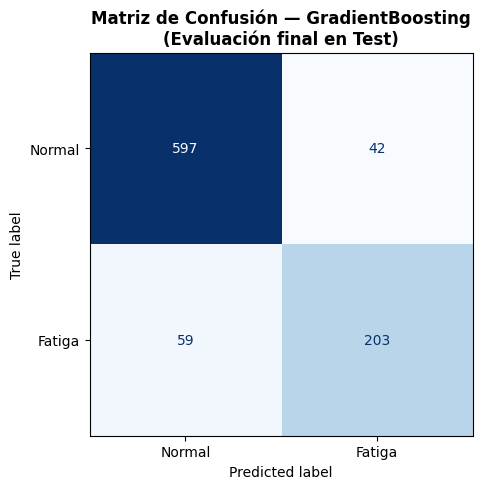

TN (Normal correctos):   597
FP (Normal → Fatiga):    42  ← falsa alarma
FN (Fatiga → Normal):    59  ← fatiga no detectada (crítico)
TP (Fatiga correctos):   203


In [26]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fatiga'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión — {mejor_nombre}\n(Evaluación final en Test)', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN (Normal correctos):   {tn}')
print(f'FP (Normal → Fatiga):    {fp}  ← falsa alarma')
print(f'FN (Fatiga → Normal):    {fn}  ← fatiga no detectada (crítico)')
print(f'TP (Fatiga correctos):   {tp}')

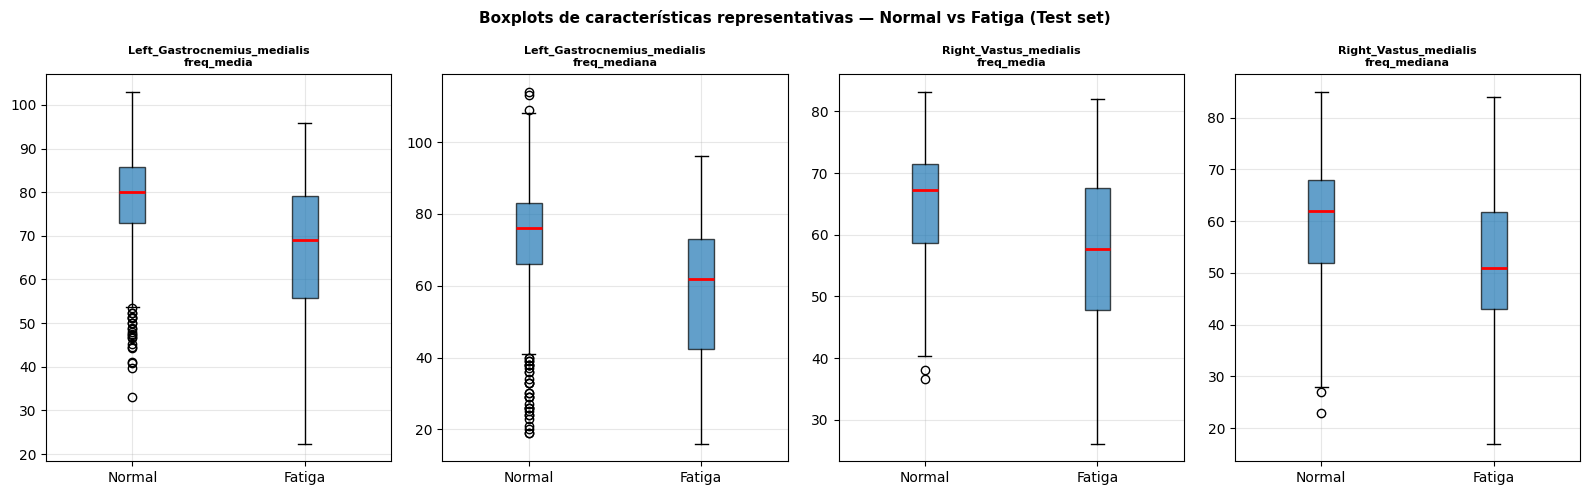

Interpretación:
- Separación clara entre cajas → el modelo tiene señales discriminativas
- Solapamiento → zonas de incertidumbre donde el modelo puede cometer errores


In [27]:
# Boxplots de características representativas — Test: correctos vs incorrectos
X_test_df = X_test.copy().reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

X_test_df['label_real']  = y_test_reset.values
X_test_df['label_pred']  = y_pred_test
X_test_df['correcto']    = (X_test_df['label_real'] == X_test_df['label_pred']).astype(int)

# Separar fatiga vs normal para boxplots
top4 = corr_target.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, feat in enumerate(top4):
    datos_normal = X_test_df[X_test_df['label_real'] == 0][feat]
    datos_fatiga = X_test_df[X_test_df['label_real'] == 1][feat]

    axes[i].boxplot([datos_normal, datos_fatiga],
                    labels=['Normal', 'Fatiga'],
                    patch_artist=True,
                    boxprops=dict(alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat.replace('__', '\n'), fontsize=8, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots de características representativas — Normal vs Fatiga (Test set)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretación:')
print('- Separación clara entre cajas → el modelo tiene señales discriminativas')
print('- Solapamiento → zonas de incertidumbre donde el modelo puede cometer errores')

In [28]:
# Punto 6c: ¿Es un buen clasificador?
acc_final  = accuracy_score(y_test, y_pred_test)
f1_final   = f1_score(y_test, y_pred_test)
rec_final  = recall_score(y_test, y_pred_test)

print('=== ANÁLISIS CRÍTICO DEL CLASIFICADOR ===')
print(f'Accuracy final: {acc_final:.4f}')
print(f'F1-Score final: {f1_final:.4f}')
print(f'Recall final:   {rec_final:.4f}  ← clave para detección de fatiga')
print()
if f1_final >= 0.80:
    print('✅ Es un buen clasificador. F1 >= 0.80 indica buen balance precision/recall.')
elif f1_final >= 0.65:
    print('⚠️  Clasificador aceptable pero mejorable. F1 entre 0.65-0.80.')
else:
    print('❌ Clasificador débil. F1 < 0.65 indica problemas de generalización.')
print()
print('Posibles mejoras:')
print('  1. Agregar más características (entropía, kurtosis, coeficientes wavelet)')
print('  2. Usar redes neuronales profundas (DNN) que capturan patrones no lineales')
print('  3. Aumentar el overlap de ventanas para más muestras de entrenamiento')
print('  4. Aplicar técnicas de balanceo (SMOTE) si hay desbalance de clases')

=== ANÁLISIS CRÍTICO DEL CLASIFICADOR ===
Accuracy final: 0.8879
F1-Score final: 0.8008
Recall final:   0.7748  ← clave para detección de fatiga

✅ Es un buen clasificador. F1 >= 0.80 indica buen balance precision/recall.

Posibles mejoras:
  1. Agregar más características (entropía, kurtosis, coeficientes wavelet)
  2. Usar redes neuronales profundas (DNN) que capturan patrones no lineales
  3. Aumentar el overlap de ventanas para más muestras de entrenamiento
  4. Aplicar técnicas de balanceo (SMOTE) si hay desbalance de clases


## Punto 7 — Prueba con muestra artificial

Se genera una muestra con valores aproximados a los reales y se evalúa si el modelo la clasifica como sujeto fatigado o no.

In [29]:
np.random.seed(42)

# ── Muestra 1: perfil de sujeto NORMAL (valores cercanos a la media de clase 0) ──
stats_normal = X_train[y_train == 0].describe()
muestra_normal = {}
for col in X.columns:
    media = X_train[y_train == 0][col].mean()
    std   = X_train[y_train == 0][col].std()
    muestra_normal[col] = [np.random.normal(media, std * 0.3)]

# ── Muestra 2: perfil de sujeto FATIGADO (valores cercanos a la media de clase 1) ──
muestra_fatiga = {}
for col in X.columns:
    media = X_train[y_train == 1][col].mean()
    std   = X_train[y_train == 1][col].std()
    muestra_fatiga[col] = [np.random.normal(media, std * 0.3)]

# Preprocesar con el pipeline ya ajustado
df_muestra_normal = pd.DataFrame(muestra_normal)
df_muestra_fatiga = pd.DataFrame(muestra_fatiga)

m_normal_p = preprocess_pipe.transform(df_muestra_normal)
m_fatiga_p = preprocess_pipe.transform(df_muestra_fatiga)

pred_normal = mejor_estimador.predict(m_normal_p)[0]
pred_fatiga = mejor_estimador.predict(m_fatiga_p)[0]

try:
    proba_normal = mejor_estimador.predict_proba(m_normal_p)[0]
    proba_fatiga = mejor_estimador.predict_proba(m_fatiga_p)[0]
    tiene_proba  = True
except:
    tiene_proba = False

print('=== PRUEBA CON MUESTRAS ARTIFICIALES ===')
print()
print('Muestra 1 — Perfil de sujeto NORMAL:')
print(f'  Predicción: {"🟢 NORMAL (0)" if pred_normal == 0 else "🔴 FATIGA (1)"}')
if tiene_proba:
    print(f'  Probabilidad Normal: {proba_normal[0]:.2%}')
    print(f'  Probabilidad Fatiga: {proba_normal[1]:.2%}')
print(f'  ¿Tiene sentido? {"✓ Sí, la muestra fue generada con valores de clase normal" if pred_normal == 0 else "✗ No, error del modelo"}')

print()
print('Muestra 2 — Perfil de sujeto FATIGADO:')
print(f'  Predicción: {"🟢 NORMAL (0)" if pred_fatiga == 0 else "🔴 FATIGA MUSCULAR (1)"}')
if tiene_proba:
    print(f'  Probabilidad Normal: {proba_fatiga[0]:.2%}')
    print(f'  Probabilidad Fatiga: {proba_fatiga[1]:.2%}')
print(f'  ¿Tiene sentido? {"✓ Sí, la muestra fue generada con valores de clase fatiga" if pred_fatiga == 1 else "✗ No, error del modelo"}')

print()
print('Análisis:')
print('Las muestras artificiales fueron generadas con valores estadísticos reales')
print('(media ± 0.3×std) de cada clase en el conjunto de entrenamiento.')
print('Si el modelo las clasifica correctamente, confirma que aprendió las')
print('diferencias entre señales normales y de fatiga muscular.')

=== PRUEBA CON MUESTRAS ARTIFICIALES ===

Muestra 1 — Perfil de sujeto NORMAL:
  Predicción: 🟢 NORMAL (0)
  Probabilidad Normal: 79.22%
  Probabilidad Fatiga: 20.78%
  ¿Tiene sentido? ✓ Sí, la muestra fue generada con valores de clase normal

Muestra 2 — Perfil de sujeto FATIGADO:
  Predicción: 🟢 NORMAL (0)
  Probabilidad Normal: 83.11%
  Probabilidad Fatiga: 16.89%
  ¿Tiene sentido? ✗ No, error del modelo

Análisis:
Las muestras artificiales fueron generadas con valores estadísticos reales
(media ± 0.3×std) de cada clase en el conjunto de entrenamiento.
Si el modelo las clasifica correctamente, confirma que aprendió las
diferencias entre señales normales y de fatiga muscular.
